In [14]:
import numpy as np
import matplotlib.pyplot as plt

n_arms = 2
arms = [0,1]

In [15]:
class Environment:
  def __init__(self,p_L,p_H,t_L,t_H,initial_states):
    self.count = [0,0]
    self.p_l = p_L
    self.p_h = p_H
    self.t_l = t_L
    self.t_h = t_H
    self.initial_states = initial_states

  def step (self,arm):
    # 1. Determine reward for the chosen arm BEFORE updating states
    current_state = self.initial_states[arm]
    p_a = self.p_l[arm] if current_state == "Low" else self.p_h[arm]
    r = np.random.binomial(1, p_a)

    # 2. Update the internal state of ALL arms (Independent Evolution)
    for i in range(2):
      self.count[i] += 1
      limit = self.t_l[i] if self.initial_states[i] == "Low" else self.t_h[i]

      if self.count[i] >= limit:
        # Toggle state: Low -> High or High -> Low
        self.initial_states[i] = "High" if self.initial_states[i] == "Low" else "Low"
        self.count[i] = 0
    return r


In [16]:
def run_ExploreThenExploit(T,env):
  N = np.power(T/n_arms,2/3).astype(int)

  r_in = np.zeros(n_arms)
  rewards = np.zeros(T)

  arm_selected = np.zeros(n_arms)

  for t in range(T):
    if t <= N:
      arm_i = t % n_arms
    else:
      arm_i = np.argmax(r_in)

    r = env.step(arm_i)
    r_in[arm_i] += r

    arm_selected[arm_i] += 1
    if t == 0:
      rewards[t] = r
    else:
      rewards[t] = r + rewards[t-1]

  return rewards, arm_selected


In [17]:
def run_UCB(T, env):
  reward = np.zeros(T)
  arm_selected = np.zeros(n_arms)

  Xin = np.zeros(n_arms)
  rin = np.zeros(n_arms)
  mu_hat = np.zeros(n_arms)

  for t in range(T):
    if t<len(arms):
      arm_i = t
    else:
      ucb_values = mu_hat + np.sqrt(2 * np.log(t+1) / Xin)
      arm_i = np.argmax(ucb_values)
    r = env.step(arm_i)
    #What our algorithm has access to:
    rin[arm_i] += r
    Xin[arm_i] += 1
    mu_hat[arm_i] =rin[arm_i] / Xin[arm_i]

    arm_selected[arm_i] += 1

    if t ==0:
      reward[t] = r
    else:
      reward[t] = r + reward[t-1]

  return reward,arm_selected

In [18]:
def run_MWbandit(T, env):
  weights = np.ones(n_arms)
  ita = np.sqrt(np.log(n_arms)/T)

  reward = np.zeros(T)
  arm_selected = np.zeros(n_arms)

  for t in range(T):

    weights_sum = np.sum(weights)
    pi = weights / weights_sum

    arm_i = np.random.choice(n_arms,p = pi)

    r = env.step(arm_i)

    l = 1 - r

    est_loss = l / pi[arm_i]

    weights[arm_i] *= np.exp(-ita * est_loss)

    arm_selected[arm_i] +=1

    if t ==0:
      reward[t] = r
    else:
      reward[t] = r + reward[t-1]

  return reward , arm_selected

# Task A.1

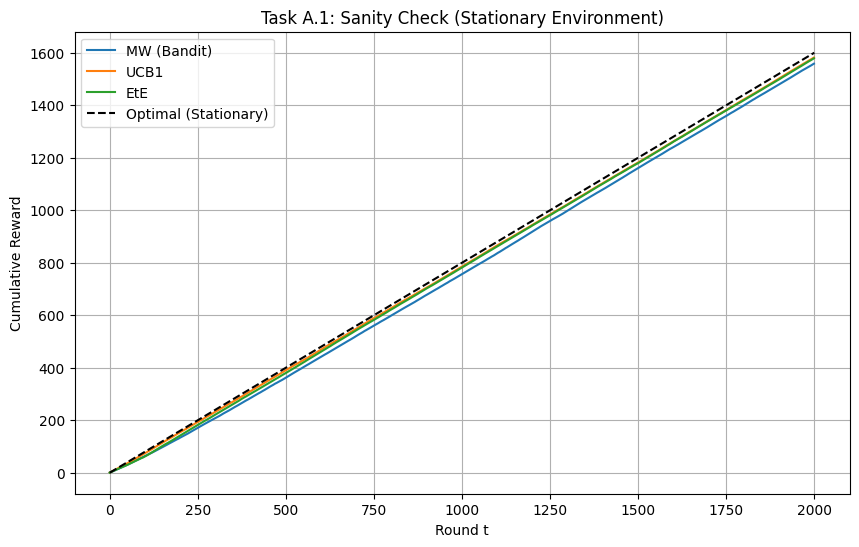

Final Rewards (Mean ± Std):
MW:  1558.30 ± 12.92
UCB: 1581.60 ± 18.26


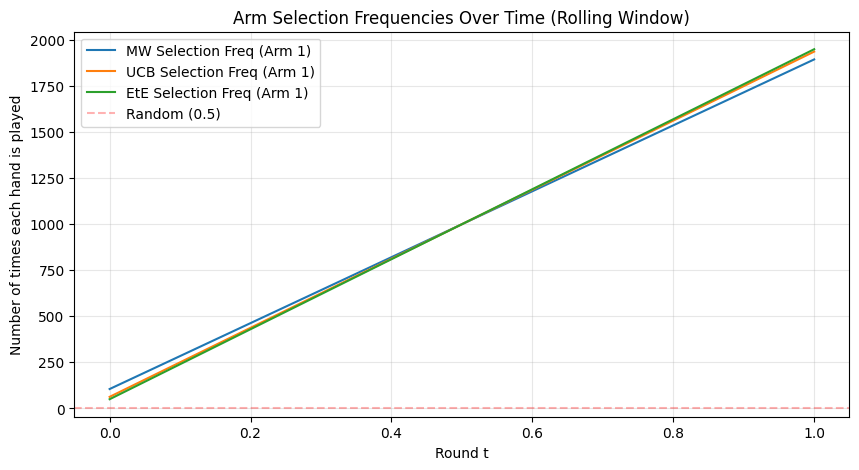

In [19]:
#Sanity check variables:
T = 2000

p_l = [0.4,0.8]
p_h = [0.4,0.8]

t_l = [50,30]
t_h = [25, 50]

initial_states = ["Low", "High"]



mc_runs = 20

rewards_mw = np.zeros((mc_runs,T))
rewards_ucb = np.zeros((mc_runs,T))
rewards_ete = np.zeros((mc_runs,T))

arms_selected_mw = np.zeros((mc_runs, n_arms))
arms_selected_ucb = np.zeros((mc_runs, n_arms))
arms_selected_ete = np.zeros((mc_runs, n_arms))

for m in range(mc_runs):
  np.random.seed(m)
  env_mw = Environment(p_l, p_h, t_l, t_h, initial_states)
  env_ete = Environment(p_l, p_h, t_l, t_h, initial_states)
  env_ucb = Environment(p_l, p_h, t_l, t_h, initial_states)

  rewards_ete[m,:], arms_selected_ete[m,:] = run_ExploreThenExploit(T, env_ete)
  rewards_ucb[m,:], arms_selected_ucb[m,:] = run_UCB(T, env_ucb)
  rewards_mw[m,:], arms_selected_mw[m,:] = run_MWbandit(T, env_mw)

mean_mw = np.mean(rewards_mw, axis=0)
mean_ucb = np.mean(rewards_ucb, axis=0)
mean_ete = np.mean(rewards_ete, axis=0)

mean_selection_mw = np.mean(arms_selected_mw, axis=0)
mean_selection_ucb = np.mean(arms_selected_ucb, axis=0)
mean_selection_ete = np.mean(arms_selected_ete, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(mean_mw, label='MW (Bandit)')
plt.plot(mean_ucb, label='UCB1')
plt.plot(mean_ete, label='EtE')
plt.plot([0, T], [0, 0.8*T], 'k--', label='Optimal (Stationary)')

plt.xlabel('Round t')
plt.ylabel('Cumulative Reward')
plt.title('Task A.1: Sanity Check (Stationary Environment)')
plt.legend()
plt.grid(True)
plt.show()

# 3. Final Values (Mean ± Std) [cite: 3, 42]
print(f"Final Rewards (Mean ± Std):")
print(f"MW:  {np.mean(rewards_mw[:,-1]):.2f} ± {np.std(rewards_mw[:,-1]):.2f}")
print(f"UCB: {np.mean(rewards_ucb[:,-1]):.2f} ± {np.std(rewards_ucb[:,-1]):.2f}")

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(mean_selection_mw, label='MW Selection Freq (Arm 1)')
plt.plot(mean_selection_ucb, label='UCB Selection Freq (Arm 1)')
plt.plot(mean_selection_ete, label='EtE Selection Freq (Arm 1)')

plt.xlabel('Round t')
plt.ylabel('Number of times each hand is played')
plt.title('Arm Selection Frequencies Over Time (Rolling Window)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Task A.2